In [12]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
x_start, x_end = 0, 2
y_start = 1
h_specific = [0.1, 0.5, 1.0, 1.5]

#Exact Solution Function
def exact_sol(x):
    return np.exp(-2 * x)

#Function for local and global errors
def calculate_errors(x_vals, y_vals):
    y_exact = exact_sol(x_vals)
    #Global error
    global_error = np.abs(y_vals - y_exact)
    
    #Local error
    local_errors = []
    for i in range(len(x_vals)-1):
        h = x_vals[i+1] - x_vals[i]
        y_ideal_step = exact_sol(x_vals[i]) + h * f(x_vals[i], exact_sol(x_vals[i]))
        local_errors.append(np.abs(exact_sol(x_vals[i+1]) - y_ideal_step))
        
    return local_errors, global_error

def f(x, y):
    return -2 * y

--- Results for h = 0.1 ---
Max Global Error: 0.0402
Average Local Error: 0.0051

--- Results for h = 0.5 ---
Max Global Error: 0.3679
Average Local Error: 0.1428

--- Results for h = 1.0 ---
Max Global Error: 1.1353
Average Local Error: 0.6445

--- Results for h = 1.5 ---
Max Global Error: 3.0183
Average Local Error: 3.0183



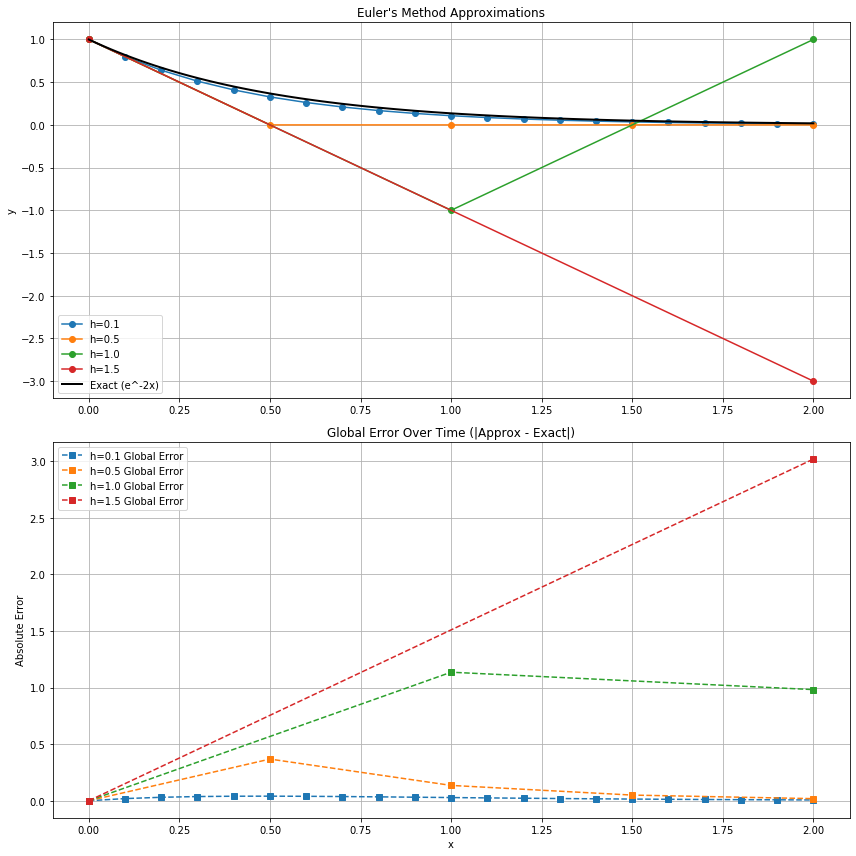

In [13]:
#Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

for h in h_specific:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = y_start

    # Euler's method
    h_actual = x_values[1] - x_values[0] if num_steps > 0 else h
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h_actual * f(x_values[i], y_values[i])

    #Error Calculation
    l_err, g_err = calculate_errors(x_values, y_values)
    
    #Approximations
    ax1.plot(x_values, y_values, 'o-', label=f"h={h}")
    
    #Global Errors on ax2
    ax2.plot(x_values, g_err, 's--', label=f"h={h} Global Error")

    #Print Results
    print(f"--- Results for h = {h} ---")
    print(f"Max Global Error: {np.max(g_err):.4f}")
    if len(l_err) > 0:
        print(f"Average Local Error: {np.mean(l_err):.4f}\n")

#Exact Solution for comparison
x_fine = np.linspace(x_start, x_end, 100)
ax1.plot(x_fine, exact_sol(x_fine), 'k', linewidth=2, label="Exact (e^-2x)")

#Graphing
ax1.set_title("Euler's Method Approximations")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True)

ax2.set_title("Global Error Over Time (|Approx - Exact|)")
ax2.set_xlabel("x")
ax2.set_ylabel("Absolute Error")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()